# ISI022 - Sistemas de Informação e Tecnologias Emergentes
### Módulo 3 · Livros-Razão Distribuídos (DLT), Blockchain e Máquinas Virtuais Turing-Completas
**Aula 02 · Mecanismos de Consenso Distribuído, a Rede Ethereum e a Máquina Virtual (EVM)**

* **Docente:** Prof. Me. André Cassulino Araújo Souza (`andre.souza@cps.sp.gov.br`)  
* **Instituição:** Centro Estadual de Educação Tecnológica Paula Souza (CEETEPS)  
* **Duração Total da Aula:** 1 hora e 40 minutos  
  * **Parte Teórico-Conceitual:** ~60 minutos  
  * **Laboratório Prático Dirigido (Hands-on):** ~40 minutos dissecando transações no [Etherscan (Sepolia Testnet)](https://sepolia.etherscan.io/) e emulando a EVM  
* **Pré-requisitos Consolidados:** Aula 01 (Criptografia assimétrica, Hashes SHA-256, Merkle Trees, Encadeamento de Blocos e Mineração básica).

---

### Objetivos de Aprendizagem da Aula:
1. **Compreender o Trilema da Blockchain** e analisar comparativamente os três grandes paradigmas de consenso distribuído: *Proof of Work* (PoW), *Proof of Stake* (PoS / Gasper na Ethereum) e *Proof of Authority* (PoA corporativo).
2. **Diferenciar os Modelos de Dados:** Contrastar o modelo UTXO (*Unspent Transaction Output*) do Bitcoin com o Modelo Baseado em Contas (*Account-based Model*) da Ethereum e suas implicações para Sistemas de Informação.
3. **Dominar a Arquitetura da Ethereum Virtual Machine (EVM):** Compreender sua operação como máquina de pilha (*Stack Machine*) de 256 bits, particionamento de memória (*Stack*, *Memory*, *Storage*, *Calldata*) e Turing-completude.
4. **Desvendar a Economia Computacional do *Gas*:** Compreender como o Gas resolve o clássico *Halting Problem* (Problema da Parada de Alan Turing), previne ataques de Negação de Serviço (DoS) e rege o mercado de taxas pós-EIP-1559.
5. **Simular e Executar em Python:** Operar simuladores de consenso, modelo de contas, uma Mini-EVM com opcodes reais e uma calculadora algorítmica de taxas EIP-1559.
6. **Auditar e Realizar Análise Forense de Transações no Etherscan:** Dissecar transações reais, decodificar chamadas de contratos inteligentes via ABI, inspecionar logs de eventos e diagnosticar reversões por *Out of Gas*.

> ### Como acompanhar esta aula
>
> Esta aula parte de uma pergunta simples: **como vários computadores, que não precisam confiar uns nos outros, conseguem concordar sobre o mesmo estado de uma rede?**
>
> A partir dessa pergunta, vamos avançar em quatro etapas:
>
> **1. Consenso** → como a rede decide qual bloco é válido.  
> **2. Modelo de dados** → como Bitcoin e Ethereum representam valores e contas.  
> **3. EVM** → como a Ethereum executa programas chamados *smart contracts*.  
> **4. Gas** → como a rede limita o trabalho computacional e cobra por esse processamento.
>
> ### Uma analogia para orientar a leitura
>
> Imagine uma empresa em que vários computadores mantêm **cópias do mesmo livro-caixa**. Quando uma nova operação chega, todos precisam concordar sobre o que pode ser registrado.
>
> - **Consenso** é o conjunto de regras para decidir qual registro é aceito.
> - **Blockchain** é o histórico compartilhado desses registros.
> - **EVM** é o ambiente que executa as regras dos contratos.
> - **Gas** funciona como um orçamento de processamento: uma operação mais trabalhosa consome mais unidades.
>
> A analogia ajuda a criar a intuição, mas os detalhes técnicos apresentados a seguir são os que definem o funcionamento real do sistema.

---
# 1. O Problema do Consenso em Redes Abertas e o Trilema da Blockchain

## 1.1 O Desafio da Coordenação sem Autoridade Central
Na **Aula 01**, constatamos que funções hash e assinaturas digitais asseguram a integridade pontual dos dados. Contudo, em uma rede aberta descentralizada com milhares de nós desconhecidos e sem hierarquia (*Peer-to-Peer*), surge um problema crítico de governança computacional:

> **Quem tem o direito legítimo de gravar o próximo lote oficial de dados (bloco) no livro-razão e em qual ordem cronológica exata?**

Se qualquer computador pudesse adicionar blocos instantaneamente e sem custo, agentes maliciosos poderiam inundar a rede com milhares de versões conflitantes por segundo (o **Problema do Gasto Duplo / *Double-Spending*** e o **Ataque Sybil**, onde um único adversário cria milhões de identidades virtuais falsas).

Para solucionar esse problema, as redes DLT utilizam **Mecanismos de Consenso Distribuído**: protocolos cripto-econômicos que coordenam nós independentes para convergir para um estado único e compartilhado da verdade contábil.

---

## 1.2 O Trilema da Escalabilidade da Blockchain (Vitalik Buterin)
Formulado por Vitalik Buterin (2014, 2017), o **Trilema da Blockchain** estabelece que é extremamente desafiador para uma rede descentralizada otimizar simultaneamente três propriedades arquiteturais fundamentais:

```mermaid
flowchart TD
    D["DESCENTRALIZAÇÃO\n(Milhares de nós validadores independentes;\nsem barreira econômica ou institucional)"] --- S["SEGURANÇA\n(Resistência a ataques bizantinos, adulteração\ne conluio de até 33% ou 51% da rede)"]
    S --- E["ESCALABILIDADE\n(Alto throughput em transações por segundo [TPS]\ne baixa latência de confirmação)"]
    E --- D

    style D fill:#e1f5fe,stroke:#0288d1,stroke-width:2px;
    style S fill:#e8f5e9,stroke:#388e3c,stroke-width:2px;
    style E fill:#fff3e0,stroke:#f57c00,stroke-width:2px;
```
* **Descentralização:** Capacidade de qualquer cidadão ou instituição rodar um nó completo (*full node*) em hardware modesto, sem depender de datacenters monopolistas.
* **Segurança:** O custo financeiro e computacional para subverter a rede deve ser astronômico, garantindo resistência a conluios e ataques de 51%.
* **Escalabilidade (*Throughput*):** Capacidade de processar milhares de transações por segundo (TPS) com finalidade em milissegundos, atendendo à demanda do comércio global.

| Modelo / Rede | Descentralização | Segurança | Escalabilidade (TPS) | Compromisso Arquitetural |
| :--- | :--- | :--- | :--- | :--- |
| **Bitcoin (PoW)** | **Altíssima** (milhares de nós globais) | **Máxima** (maior poder computacional do planeta) | **Baixa** (~7 TPS, blocos a cada 10 min) | Sacrifica throughput para blindar descentralização e segurança. |
| **Ethereum L1 (PoS)** | **Muito Alta** (> 1 milhão de validadores) | **Muito Alta** (centenas de bilhões em stake) | **Moderada** (~15 a 30 TPS, slots de 12s) | Usa Rollups L2 (Arbitrum, Optimism, zkSync) para escalar. |
| **Redes Permissionadas / PoA (Hyperledger)** | **Baixa** (consorciada a 5-20 entidades) | **Alta** (segurança jurídica e autenticação mútua) | **Altíssima** (1.000 a 10.000+ TPS) | Sacrifica descentralização aberta em prol de altíssimo desempenho. |

---
## 1.3 Taxonomia dos Algoritmos de Consenso: PoW vs. PoS vs. PoA

### A. Proof of Work (PoW - Prova de Trabalho)
* **Arquétipo:** Bitcoin (NAKAMOTO, 2008), Litecoin.
* **Mecanismo:** Mineradores competem continuamente alocando energia elétrica e poder de processamento bruto (ASICs) para encontrar um número (*Nonce*) que resulte em um hash abaixo do *Target* de dificuldade da rede.
* **Regra de Escolha de Cadeia:** Regra da Cadeia com Maior Trabalho Acumulado (*Nakamoto Consensus* / *Heaviest Chain*).
* **Finalidade:** **Probabilística**. Um bloco recém-minerado nunca possui finalidade absoluta instantânea; sua certeza estatística aumenta à medida que blocos subsequentes são empilhados sobre ele (convencionalmente, 6 confirmações $\\approx 60$ minutos no Bitcoin para transações críticas).
* **Ponto Crítico:** Consumo elétrico maciço em nível de países inteiros e tendência à centralização de hardware em grandes parques industriais de mineração.

---

### B. Proof of Stake (PoS - Prova de Participação / Ethereum Gasper)
* **Arquétipo:** Ethereum (pós-transição histórica *The Merge*, 15 de setembro de 2022).
* **Mecanismo:** A mineração por hardware é extinta. A segurança é ancorada em **capital financeiro bloqueado (*Staking*)**. Para ser um validador, o agente deve depositar **32 ETH** em um contrato inteligente oficial de depósito.
* **Organização Temporal:**
  * **Slot:** Intervalo estrito de **12 segundos**. A cada slot, um validador é pseudo-aleatoriamente selecionado pelo protocolo (via algoritmo RANDAO) para atuar como **Propositor do Bloco (*Block Proposer*)**.
  * **Comitê de Atestação:** Em cada slot, centenas de outros validadores independentes analisam o bloco proposto e emitem **votos criptográficos de aprovação (*Attestations*)**.
  * **Epoch:** Conjunto de **32 slots** consecutivos ($32 \\times 12\\text{s} = 6,4\\text{ minutos} = 384\\text{ segundos}$).
* **Finalidade Determinística (Gasper = Casper FFG + LMD-GHOST):**
  * *LMD-GHOST:* Seleciona a ponta da cadeia em tempo real a cada slot.
  * *Casper FFG:* Confere finalidade criptográfica irreversível. Quando duas épocas consecutivas recebem $\\ge 2/3$ dos votos do conjunto global de validadores, o bloco é **Finalizado (*Finalized*)** (ocorre tipicamente em 2 épocas $\\approx 12,8\\text{ minutos}$). Uma vez finalizado, reverter o bloco exigiria que um invasor queimasse intencionalmente ao menos 33% de todo o capital em stake da rede mundial.
* **Teoria dos Jogos e Mecanismos Punitivos:**
  * **Penalidade de Inatividade (*Inactivity Leak*):** Validadores que ficarem offline perdem pequenas frações de saldo correspondentes ao custo de oportunidade.
  * **Slashing (Punição Extrema):** Se um validador agir de má-fé (ex: propor dois blocos diferentes no mesmo slot ou emitir atestações conflitantes para provocar forks), o protocolo aplica *Slashing*: confisca e **destrói permanentemente** parte substancial do seu stake de 32 ETH e o **ejeta compulsória e irrevogavelmente** da rede.
* **Impacto Energético:** Redução documentada de **mais de 99,95%** no consumo energético da rede Ethereum (passando de gigawatts equivalentes a países para o consumo equivalente a poucas residências).

---

### C. Proof of Authority (PoA - Prova de Autoridade)
* **Arquétipo:** Redes corporativas e de consórcio (Hyperledger Besu, Quorum, GoQuorum, R3 Corda, redes de homologação Sepolia/Clique).
* **Mecanismo:** A validação não depende de puzzles matemáticos (PoW) nem de riqueza financeira acumulada (PoS). O direito de criar blocos é outorgado a uma lista estrita de nós operados por entidades jurídicas autenticadas e auditadas (ex: Consórcio Bancário Nacional, FIESP, Receita Federal, Cadeia Farmacêutica).
* **Vantagens:** Latência na casa de centenas de milissegundos, taxa de transação virtualmente nula ou previsível, finalidade determinística imediata e alto rendimento transacional (milhares de TPS).
* **Desvantagens:** Requer governança centralizada prévia; inadequado para sistemas públicos desprovidos de permissão (*permissionless*).

### Visualização 1 — O que cada mecanismo usa para participar do consenso
O gráfico abaixo não atribui uma “nota” aos mecanismos. Ele apenas transforma em uma imagem os **recursos de participação descritos nesta aula**.


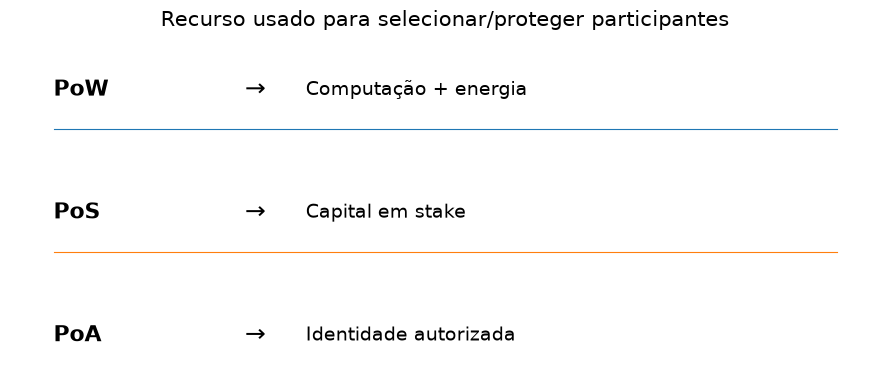

In [1]:
import matplotlib.pyplot as plt

mecanismos = ["PoW", "PoS", "PoA"]

recursos = ["Computação + energia", "Capital em stake", "Identidade autorizada"]

fig, ax = plt.subplots(figsize=(9, 3.8))

ax.axis("off")

for i, (m, r) in enumerate(zip(mecanismos, recursos)):
    y = 2 - i
    ax.text(0.05, y, m, fontsize=16, fontweight="bold", va="center")
    ax.text(0.27, y, "→", fontsize=18, va="center")
    ax.text(0.34, y, r, fontsize=14, va="center")
    if i < 2:
        ax.plot([0.05, 0.95], [y - 0.32, y - 0.32], linewidth=0.8)

ax.set_xlim(0, 1)

ax.set_ylim(-0.2, 2.35)

ax.set_title("Recurso usado para selecionar/proteger participantes", fontsize=15, pad=15)

plt.tight_layout()

plt.show()

---
## 1.4 Matriz Comparativa Rigorosa dos Modelos de Consenso

| Critério Arquitetural | Proof of Work (PoW) | Proof of Stake (PoS / Gasper) | Proof of Authority (PoA) |
| :--- | :--- | :--- | :--- |
| **Exemplo Canônico** | Bitcoin, Dogecoin, Monero | Ethereum, Cardano, Solana (DPoS) | Hyperledger Besu, Sepolia, Consórcios |
| **Recurso de Escassez** | Eletricidade e Hardware ASIC | Moeda Nativa em Custódia (*Stake*) | Identidade Jurídica e Chaves Certificadas |
| **Seleção do Propositor** | Primeiro a achar o hash válido | Sorteio ponderado pelo saldo em stake | Escala rotativa (*Round-Robin*) autorizada |
| **Consumo Energético** | Massivo (TWh/ano, impacto de carbono) | **Mínimo** (~99,95% menor que PoW) | **Desprezível** (similar a um servidor web) |
| **Tempo de Bloco / Latência** | ~10 minutos (Bitcoin) | **12 segundos** (Slots na Ethereum) | **0,5 a 2 segundos** |
| **Tipo de Finalidade** | Probabilística (requer ~6 blocos) | **Determinística Absoluta** (~12,8 min) | **Determinística Imediata** (1 bloco) |
| **Vetor de Ataque Crítico** | Ataque de 51% do Hashrate | Ataque de 33% (liveness) ou 66% (safety) | Conluio da maioria das entidades aprovadas |
| **Punição para Fraude** | Gasto inútil de eletricidade sem retorno | **Slashing** (destruição do capital em ETH) | Revogação legal e processo judicial |
| **Aderência Empresarial** | Baixa para TI corporativa (lento e caro) | Alta para DApps públicas e DeFi | **Máxima para Consórcios Privados (B2B)** |

```mermaid
flowchart TD
    Inicio(["Nova Transação Submetida à Rede"]) --> Escolha{"Qual o Mecanismo<br/>de Consenso?"}
    
    Escolha -- "Proof of Work (PoW)" --> W1["Mineradores calculam bilhões de SHA-256 por segundo"]
    W1 --> W2["Primeiro a encontrar Hash < Target vence"]
    W2 --> W3["Propaga bloco; rede adota regra da cadeia mais pesada"]
    W3 --> W4["Finalidade PROBABILÍSTICA<br/>(Aguardar 6 blocos)"]
    
    Escolha -- "Proof of Stake (PoS)" --> S1["Validador é sorteado pseudo-aleatoriamente no Slot de 12s"]
    S1 --> S2["Comitê de centenas de validadores atesta o bloco"]
    S2 --> S3["Tentativa de fraude? → SLASHING<br/>(Queima de ETH)"]
    S3 --> S4["Finalidade DETERMINÍSTICA<br/>em 2 Epochs (Casper FFG)"]
    
    Escolha -- "Proof of Authority (PoA)" --> A1["Rodízio estrito entre nós corporativos autenticados"]
    A1 --> A2["Assinatura criptográfica institucional válida?"]
    A2 --> A3["Bloco validado e propagado pela rede"]
    A3 --> A4["Finalidade DETERMINÍSTICA IMEDIATA<br/>(< 2 segundos)"]

    style W4 fill:#ffebee,stroke:#c62828
    style S4 fill:#e8f5e9,stroke:#2e7d32
    style A4 fill:#e3f2fd,stroke:#1565c0
```



In [2]:
import hashlib

import time

import random

print("=" * 90)

print("SIMULADOR DIDÁTICO: COMO DIFERENTES REDES CHEGAM A UM ACORDO")

print("=" * 90)

print("""
Nesta atividade vamos observar três ideias:

  • PoW → vence quem encontra primeiro uma solução computacional válida.
  • PoS → um validador é escolhido e seu comportamento pode ser punido
          quando existem provas de uma ação proibida.
  • PoA → participantes previamente autorizados se revezam para propor blocos.

A ideia não é apenas saber QUEM foi escolhido, mas entender POR QUE
a rede aceita ou rejeita o comportamento apresentado.
""")

print("\n" + "=" * 90)

print("[1] PROOF OF WORK — PROVA DE TRABALHO")

print("=" * 90)

print("""
Imagine que vários participantes estejam tentando resolver o mesmo desafio.

Eles não precisam descobrir uma resposta "inteligente".
Precisam testar várias possibilidades até encontrar um resultado
que atenda à regra definida pela rede.

Neste exemplo, a regra será:

    o Hash precisa começar com 0000
""")

def simular_pow(bloco_id, transacao, dificuldade=4):

    target = "0" * dificuldade
    nonce = 0
    t0 = time.time()

    while True:
        payload = f"{bloco_id}{transacao}{nonce}".encode()
        h = hashlib.sha256(payload).hexdigest()

        if h.startswith(target):
            delta_t = time.time() - t0
            return nonce, h, delta_t

        nonce += 1

bloco_id = 101

transacao = "Alice->Bob: 5 BTC"

print(f"Transação do exemplo: {transacao}")

print("Desafio: encontrar um Hash que comece com 0000.")

print("\nMinerando...")

nonce_res, hash_res, tempo_pow = simular_pow(
    bloco_id,
    transacao,
    dificuldade=4
)

print("\nRESULTADO")

print(f"  Número de tentativas até encontrar uma solução: {nonce_res:,}")

print(f"  Hash encontrado: {hash_res}")

print(f"  Tempo de execução no computador: {tempo_pow:.4f} segundos")

print("""
O que aconteceu?

O computador não "sabia" qual seria o nonce correto.
Ele foi testando valores até encontrar um que produzisse um Hash
compatível com a regra.

Portanto, o trabalho está justamente em realizar muitas tentativas.

→ PoW utiliza trabalho computacional para tornar a produção do bloco custosa.
""")

print("\n" + "=" * 90)

print("[2] PROOF OF STAKE — PROVA DE PARTICIPAÇÃO")

print("=" * 90)

print("""
Agora o processo é diferente.

Em vez de todos competirem realizando cálculos, alguns participantes
possuem ETH bloqueado como garantia (stake).

Nesta simulação, quanto maior o stake, maior o peso no sorteio.
""")

validadores_pos = [
    {"nome": "Node_Alpha", "stake_eth": 32},
    {"nome": "Node_Beta",  "stake_eth": 96},
    {"nome": "Node_Gamma", "stake_eth": 64},
    {"nome": "Node_Delta", "stake_eth": 32}
]

print("Validadores participantes:")

for v in validadores_pos:
    print(f"  • {v['nome']}: {v['stake_eth']} ETH em stake")

def selecionar_propositor_pos(validadores):

    pesos = [v["stake_eth"] for v in validadores]

    return random.choices(
        validadores,
        weights=pesos,
        k=1
    )[0]

propositor = selecionar_propositor_pos(validadores_pos)

print("\nSORTEIO DO PROPOSITOR")

print(f"  Validador selecionado: {propositor['nome']}")

print(f"  Stake: {propositor['stake_eth']} ETH")

print("""
O participante selecionado agora pode propor um bloco.

Mas ser selecionado não significa que ele possa fazer qualquer coisa.

A rede possui regras para verificar se o validador está agindo corretamente.
""")

print("\n" + "-" * 90)

print("SITUAÇÃO DE TESTE: O VALIDADOR ASSINOU DOIS BLOCOS DIFERENTES")

print("-" * 90)

print("""
Para tornar a detecção visível, vamos criar uma situação de fraude.

Um mesmo validador não deve assinar duas propostas conflitantes
para o mesmo slot.

Vamos imaginar:

    Slot 42

    Primeiro voto:
        Node_Beta → Bloco A

    Segundo voto:
        Node_Beta → Bloco B

O problema é que os dois blocos representam propostas diferentes
para o mesmo momento da rede.
""")

votos_recebidos = {}

slot = 42

primeiro_bloco = "Bloco_A"

segundo_bloco = "Bloco_B"

validador = "Node_Beta"

print("1º voto recebido:")

print(f"   Validador: {validador}")

print(f"   Slot: {slot}")

print(f"   Bloco assinado: {primeiro_bloco}")

votos_recebidos[(validador, slot)] = primeiro_bloco

print("\nA rede registra esse voto.")

print("Até aqui, não existe nenhuma evidência de comportamento irregular.")

print("\n2º voto recebido:")

print(f"   Validador: {validador}")

print(f"   Slot: {slot}")

print(f"   Bloco assinado: {segundo_bloco}")

voto_anterior = votos_recebidos.get((validador, slot))

print("\nVERIFICAÇÃO DA REDE")

if voto_anterior is not None and voto_anterior != segundo_bloco:

    print("  ❌ INCONSISTÊNCIA ENCONTRADA!")
    print()
    print(f"  A rede já tinha registrado:")
    print(f"      {validador} → {voto_anterior}")
    print()
    print(f"  Agora recebeu:")
    print(f"      {validador} → {segundo_bloco}")
    print()
    print("  Evidência:")
    print("      O MESMO validador assinou DOIS blocos diferentes")
    print("      para o MESMO slot.")
    print()
    print("  Portanto, a rede possui uma evidência verificável")
    print("  de comportamento proibido.")
    print()
    print("  → SLASHING: o stake é utilizado como garantia")
    print("    e uma penalidade pode ser aplicada.")

    alvo_slashing = next(
        v for v in validadores_pos
        if v["nome"] == validador
    )

    multa_slashing = alvo_slashing["stake_eth"] * 0.5

    alvo_slashing["stake_eth"] -= multa_slashing

    print()
    print(f"  Stake antes da punição: {alvo_slashing['stake_eth'] + multa_slashing:.1f} ETH")
    print(f"  Penalidade simulada:    {multa_slashing:.1f} ETH")
    print(f"  Stake após a punição:   {alvo_slashing['stake_eth']:.1f} ETH")

else:

    print("  ✓ Nenhum comportamento proibido foi identificado.")

print("""
POR QUE O VALIDADOR FOI DETECTADO?

Não foi por causa do nome "Node_Beta".
Não foi porque a rede "suspeitou" dele.

A detecção ocorreu porque existiam DOIS REGISTROS verificáveis:

    mesmo validador
          +
    mesmo slot
          +
    dois blocos diferentes assinados

Essa evidência pode ser verificada pelos demais participantes da rede.
""")

print("\n" + "=" * 90)

print("[3] PROOF OF AUTHORITY — PROVA DE AUTORIDADE")

print("=" * 90)

print("""
Neste modelo, os participantes que podem produzir blocos são conhecidos
e previamente autorizados.

Em vez de realizar uma competição computacional ou um sorteio baseado
em stake, podemos utilizar uma ordem definida de participantes.

Nesta simulação, eles irão se revezar.
""")

autoridades_poa = [
    {"orgao": "Instituição A", "chave": "0xA001...01"},
    {"orgao": "Instituição B", "chave": "0xB002...02"},
    {"orgao": "Instituição C", "chave": "0xC003...03"}
]

def propor_bloco_poa(slot_numero, autoridades):

    indice = (slot_numero - 1) % len(autoridades)

    return autoridades[indice]

print("Participantes autorizados:")

for autoridade in autoridades_poa:
    print(f"  • {autoridade['orgao']}")

print("\nRODÍZIO DOS PROPONENTES")

for slot in range(1, 7):

    lider = propor_bloco_poa(
        slot,
        autoridades_poa
    )

    print(
        f"  Slot {slot}: "
        f"{lider['orgao']} → propõe e assina o bloco"
    )

print("""
O que observar?

Não existe uma corrida computacional como no PoW.

Também não existe, nesta simplificação, um sorteio ponderado
pelo valor em stake como no exemplo de PoS.

A rede sabe antecipadamente quais participantes estão autorizados
e pode organizar o processo de forma determinística.
""")

print("\n" + "=" * 90)

print("RESUMO DA SIMULAÇÃO")

print("=" * 90)

print("""
┌────────────────────┬─────────────────────────────────────────────────────┐
│ Mecanismo          │ Ideia principal                                     │
├────────────────────┼─────────────────────────────────────────────────────┤
│ PoW                │ Competição baseada em trabalho computacional        │
│ PoS                │ Participação baseada em stake + regras de validação │
│ PoA                │ Participação baseada em autoridades autorizadas     │
└────────────────────┴─────────────────────────────────────────────────────┘

A principal diferença não está apenas em "quem produz o bloco".

Cada mecanismo responde de uma maneira diferente à pergunta:

    "Como a rede pode confiar que o próximo bloco
     segue as regras estabelecidas?"
""")

print("=" * 90)

SIMULADOR DIDÁTICO: COMO DIFERENTES REDES CHEGAM A UM ACORDO

Nesta atividade vamos observar três ideias:

  • PoW → vence quem encontra primeiro uma solução computacional válida.
  • PoS → um validador é escolhido e seu comportamento pode ser punido
          quando existem provas de uma ação proibida.
  • PoA → participantes previamente autorizados se revezam para propor blocos.

A ideia não é apenas saber QUEM foi escolhido, mas entender POR QUE
a rede aceita ou rejeita o comportamento apresentado.


[1] PROOF OF WORK — PROVA DE TRABALHO

Imagine que vários participantes estejam tentando resolver o mesmo desafio.

Eles não precisam descobrir uma resposta "inteligente".
Precisam testar várias possibilidades até encontrar um resultado
que atenda à regra definida pela rede.

Neste exemplo, a regra será:

    o Hash precisa começar com 0000

Transação do exemplo: Alice->Bob: 5 BTC
Desafio: encontrar um Hash que comece com 0000.

Minerando...

RESULTADO
  Número de tentativas até encontr

### Antes de comparar: por que o modelo de dados importa?
Quando uma transferência acontece, a rede precisa responder a uma pergunta básica:

> **“Onde está o valor antes da operação e como o novo estado será registrado depois dela?”**

Bitcoin e Ethereum respondem a essa pergunta de maneiras diferentes.

Uma forma intuitiva de visualizar:
- **UTXO:** pense em várias cédulas digitais que são consumidas e substituídas por novas cédulas.
- **Contas:** pense em registros de saldo que são atualizados conforme as transações são processadas.

Essa diferença influencia a forma de validar transações e de construir aplicações sobre cada rede.

---
# 2. De Moeda Digital a Computador Mundial: Bitcoin vs. Rede Ethereum

## 2.1 O Modelo UTXO (*Unspent Transaction Output*) do Bitcoin
O protocolo Bitcoin (NAKAMOTO, 2008) foi projetado estritamente como um **Sistema de Dinheiro Eletrônico P2P**. Ele não mantém um registro centralizado com o saldo de cada usuário (não existe uma coluna `saldo = 50 BTC`). Em vez disso, seu estado baseia-se em **Saídas de Transação Não Gastas (UTXOs)**:

* Uma UTXO comporta-se exatamente como uma **cédula física de dinheiro**.
* Se você possui 10 BTC e deseja transferir 2 BTC para Bob:
  1. Você é obrigado a **destruir (consumir)** a sua cédula inteira de 10 BTC como *Input* da transação.
  2. A transação gera dois novos *Outputs*: uma nova cédula de 2 BTC com a chave pública de Bob e uma nova cédula de troco (*Change*) de 8 BTC devolvida à sua carteira.
* **A Linguagem Script do Bitcoin:** O Bitcoin possui uma linguagem de programação interna chamada *Script*. Contudo, ela é **deliberadamente Não-Turing Completa**:
  * Não possui loops (`for`, `while`) nem recursão.
  * O objetivo foi evitar ataques de negação de serviço (DoS) por loops infinitos e manter o código estritamente previsível para verificação de assinaturas e travas de tempo (*timelocks*).

---

## 2.2 O Modelo Baseado em Contas (*Account-based Model*) da Ethereum
Proposta por Vitalik Buterin no final de 2013 e lançada em 2015 com arquitetura formalizada por Gavin Wood no *Yellow Paper*, a rede **Ethereum** alterou radicalmente essa abordagem para criar um **Computador Mundial Descentralizado (*World Computer*)**:

Em vez de cédulas UTXO fragmentadas, a Ethereum opera sob o **Modelo Baseado em Contas**, exatamente idêntico a um sistema de contas bancárias tradicional: o estado global é uma tabela associativa que mapeia endereços de 160 bits (20 bytes) para seus respectivos estados internos.

Existem **duas categorias fundamentais de contas** na Ethereum:

```mermaid
classDiagram
    class Account {
        +uint256 nonce
        +uint256 balance
        +bytes32 storageRoot
        +bytes32 codeHash
    }
    class EOA {
        <<Externally Owned Account>>
        +Controlada por Chave Privada humana
        +storageRoot = Hash Vazio
        +codeHash = Hash Vazio
        +Pode iniciar transações ativamente
    }
    class ContractAccount {
        <<Smart Contract>>
        +Controlada por Bytecode imutável
        +storageRoot = Raiz da Árvore de Estado
        +codeHash = Hash Keccak do Bytecode
        +Reage apenas quando chamada por EOA ou outro contrato
    }
    Account <|-- EOA
    Account <|-- ContractAccount
```

### A Quádrupla de Dados de Toda Conta Ethereum:
1. **`nonce`:**
   * Em uma EOA: Contor sequencial de quantas transações a conta já enviou. Previne crucialmente o **Ataque de Reexecução (*Replay Attack*)**, impedindo que a mesma transação seja duplicada maliciosamente.
   * Em um Contrato: Contador de quantos outros contratos inteligentes foram criados por este contrato.
2. **`balance`:** Quantidade de Wei (1 Ether = $10^{18}$ Wei) de propriedade da conta.
3. **`storageRoot`:** O hash de 256 bits da raiz da Árvore Merkle Patricia (*Modified Merkle Patricia Trie*) que ancora todo o armazenamento permanente de variáveis do contrato inteligente. Em contas EOA, este campo é fixo como o hash de uma árvore vazia.
4. **`codeHash`:** O hash Keccak-256 do código compilado (bytecode) que reside na conta. Em EOAs, este campo é o hash de uma string vazia (não possuem código executável).

---

## 2.3 A Ethereum como uma Máquina de Estados Finita Transacional
No *Yellow Paper* da Ethereum, Gavin Wood formalizou a rede não apenas como um histórico estático de dados, mas como uma **Máquina de Estados Finita Transacional Global**:

$$\sigma_{t+1} = \Upsilon(\sigma_t, T)$$

* $\sigma_t$: O Estado Global da Ethereum no instante $t$ (o mapa completo de todas as contas, saldos e variáveis de todos os smart contracts do planeta).
* $T$: Uma transação válida (transferência ou execução de contrato).
* $\Upsilon$: A **Função de Transição de Estado da EVM**, um autômato determinístico rigoroso.
* $\sigma_{t+1}$: O novo Estado Global após a execução precisa de $T$.

Se a transação $T$ for bem-sucedida, o estado avança para $\sigma_{t+1}$. Se $T$ falhar (por exemplo, saldo insuficiente ou falta de gas), a função de transição realiza um **Rollback Atômico** ($\sigma_{t+1} = \sigma_t$), desfazendo todas as escritas de variáveis, mas cobrando as taxas do remetente pelo trabalho computacional despendido pelos nós.


In [3]:
print("=" * 80)

print("COMPARAÇÃO DE MODELO DE DADOS: UTXO vs. CONTAS")

print("=" * 80)

print("\n[1] PARADIGMA UTXO (Consumo de Cédulas e Emissão de Troco):")

conjunto_utxos = {
    "tx01:0": {"dono": "Alice", "valor": 10.0}, # Cédula de 10 BTC
    "tx02:1": {"dono": "Alice", "valor": 5.0}   # Cédula de 5 BTC
}

def transferir_utxo(remetente, destinatario, valor_envio, conjunto):
    print(f"  -> {remetente} deseja enviar {valor_envio} BTC para {destinatario}...")
    # Coletando UTXOs suficientes do remetente
    utxos_disponiveis = {k: v for k, v in conjunto.items() if v["dono"] == remetente}
    total_acumulado = sum(v["valor"] for v in utxos_disponiveis.values())

    if total_acumulado < valor_envio:
        raise ValueError("Saldo insuficiente em UTXOs!")

    # Consumindo as UTXOs antigas (destruição de cédulas)
    inputs_consumidos = list(utxos_disponiveis.keys())
    for k in inputs_consumidos:
        del conjunto[k]

    # Gerando novas UTXOs (novo pagamento e troco)
    novo_id_pagamento = f"tx03:0"
    conjunto[novo_id_pagamento] = {"dono": destinatario, "valor": valor_envio}

    troco = total_acumulado - valor_envio
    if troco > 0:
        novo_id_troco = f"tx03:1"
        conjunto[novo_id_troco] = {"dono": remetente, "valor": troco}

    print(f"     Inputs destruídos: {inputs_consumidos} (Total: {total_acumulado} BTC)")
    print(f"     Outputs gerados: {destinatario} recebeu {valor_envio} BTC | Troco de Alice: {troco} BTC")

transferir_utxo("Alice", "Bob", 7.0, conjunto_utxos)

print(f"  Estado final das UTXOs ativas: {conjunto_utxos}")

print("\n[2] PARADIGMA BASEADO EM CONTAS (Estado Mutável e Proteção por Nonce):")

tabela_contas = {
    "0xAlice": {"nonce": 0, "balance_eth": 15.0, "is_contract": False},
    "0xBob":   {"nonce": 0, "balance_eth": 0.0,  "is_contract": False}
}

def transferir_account(remetente, destinatario, valor, nonce_informado, contas):
    print(f"  -> Tentativa de Envio: {remetente} -> {destinatario} | Valor: {valor} ETH | Nonce Informado: {nonce_informado}")
    conta_rem = contas[remetente]

    # 1. Validação estrita do Nonce contra Replay Attacks
    if nonce_informado != conta_rem["nonce"]:
        print(f"     ❌ REJEIÇÃO: Nonce Inválido! Esperado: {conta_rem['nonce']}, Recebido: {nonce_informado}")
        print("        (Tentativa de ataque de reexecução de transação duplicada!)")
        return False

    # 2. Validação de Saldo
    if conta_rem["balance_eth"] < valor:
        print("     ❌ REJEIÇÃO: Saldo insuficiente!")
        return False

    # 3. Transição Atômica de Estado
    conta_rem["balance_eth"] -= valor
    conta_rem["nonce"] += 1 # Incremento obrigatório do Nonce
    contas[destinatario]["balance_eth"] += valor

    print(f"     ✅ SUCESSO: Novo Saldo Remetente: {conta_rem['balance_eth']} ETH (Próximo Nonce: {conta_rem['nonce']})")
    print(f"                 Novo Saldo Destinatário: {contas[destinatario]['balance_eth']} ETH")
    return True

transferir_account("0xAlice", "0xBob", 7.0, nonce_informado=0, contas=tabela_contas)

print("\n  🚨 Simulando Replay Attack (Hacker tenta reenviar o mesmo pacote assinado da transação anterior):")

transferir_account("0xAlice", "0xBob", 7.0, nonce_informado=0, contas=tabela_contas)

COMPARAÇÃO DE MODELO DE DADOS: UTXO vs. CONTAS

[1] PARADIGMA UTXO (Consumo de Cédulas e Emissão de Troco):
  -> Alice deseja enviar 7.0 BTC para Bob...
     Inputs destruídos: ['tx01:0', 'tx02:1'] (Total: 15.0 BTC)
     Outputs gerados: Bob recebeu 7.0 BTC | Troco de Alice: 8.0 BTC
  Estado final das UTXOs ativas: {'tx03:0': {'dono': 'Bob', 'valor': 7.0}, 'tx03:1': {'dono': 'Alice', 'valor': 8.0}}

[2] PARADIGMA BASEADO EM CONTAS (Estado Mutável e Proteção por Nonce):
  -> Tentativa de Envio: 0xAlice -> 0xBob | Valor: 7.0 ETH | Nonce Informado: 0
     ✅ SUCESSO: Novo Saldo Remetente: 8.0 ETH (Próximo Nonce: 1)
                 Novo Saldo Destinatário: 7.0 ETH

  🚨 Simulando Replay Attack (Hacker tenta reenviar o mesmo pacote assinado da transação anterior):
  -> Tentativa de Envio: 0xAlice -> 0xBob | Valor: 7.0 ETH | Nonce Informado: 0
     ❌ REJEIÇÃO: Nonce Inválido! Esperado: 1, Recebido: 0
        (Tentativa de ataque de reexecução de transação duplicada!)


False


### Visualização 2 — O mesmo pagamento visto pelos dois modelos
Na simulação anterior, Alice enviou 7 unidades para Bob. O gráfico resume o estado final produzido pelos dois modelos.


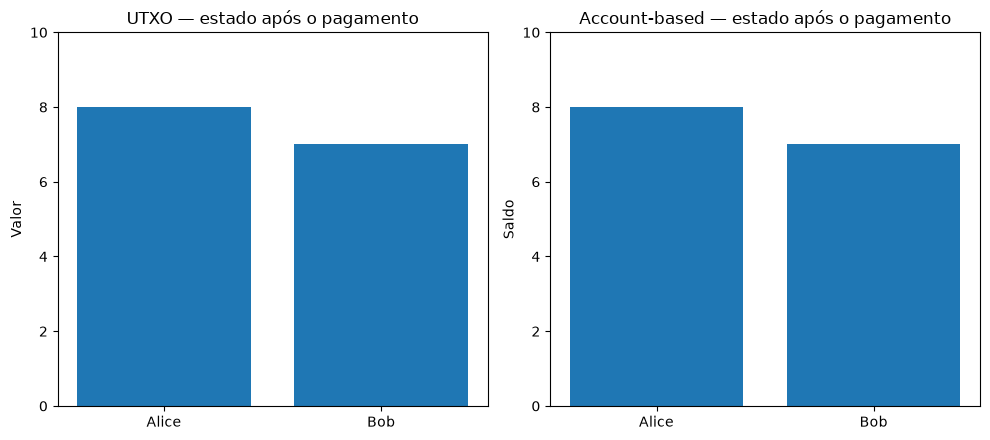

In [4]:
utxo_alice, utxo_bob = 8.0, 7.0

account_alice, account_bob = 8.0, 7.0

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].bar(["Alice", "Bob"], [utxo_alice, utxo_bob])

axes[0].set_title("UTXO — estado após o pagamento")

axes[0].set_ylabel("Valor")

axes[0].set_ylim(0, 10)

axes[1].bar(["Alice", "Bob"], [account_alice, account_bob])

axes[1].set_title("Account-based — estado após o pagamento")

axes[1].set_ylabel("Saldo")

axes[1].set_ylim(0, 10)

plt.tight_layout()

plt.show()


### Visualização 3 — Onde os dados ficam durante a execução
Em vez de memorizar os nomes isoladamente, pense em duas perguntas: **o dado é temporário ou persistente?** e **o contrato pode alterá-lo?**


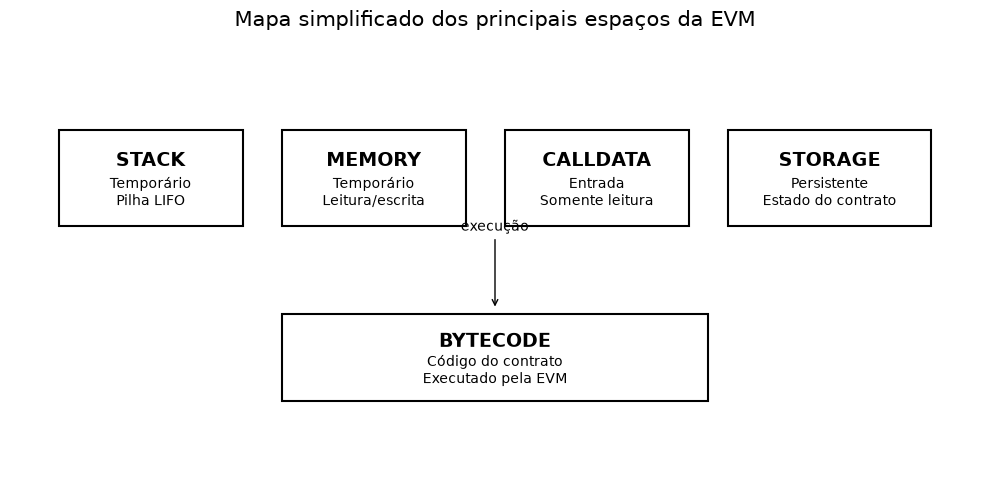

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.axis("off")

boxes = [
    (0.05, 0.58, 0.19, 0.22, "STACK", "Temporário\nPilha LIFO"),
    (0.28, 0.58, 0.19, 0.22, "MEMORY", "Temporário\nLeitura/escrita"),
    (0.51, 0.58, 0.19, 0.22, "CALLDATA", "Entrada\nSomente leitura"),
    (0.74, 0.58, 0.21, 0.22, "STORAGE", "Persistente\nEstado do contrato"),
    (0.28, 0.18, 0.44, 0.20, "BYTECODE", "Código do contrato\nExecutado pela EVM"),
]

for x, y, w, h, title, desc in boxes:
    rect = plt.Rectangle((x, y), w, h, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + w/2, y + h*0.68, title, ha="center", va="center",
            fontsize=14, fontweight="bold")
    ax.text(x + w/2, y + h*0.35, desc, ha="center", va="center", fontsize=10)

ax.annotate("execução", xy=(0.50, 0.39), xytext=(0.50, 0.57),
            ha="center", arrowprops=dict(arrowstyle="->"))

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

ax.set_title("Mapa simplificado dos principais espaços da EVM", fontsize=15, pad=12)

plt.tight_layout()

plt.show()

---
# 3. A Arquitetura da Máquina Virtual Ethereum (EVM)

## 3.1 O que é a EVM em Ciência da Computação?
A **Ethereum Virtual Machine (EVM)** é o motor computacional de processamento de contratos inteligentes da rede Ethereum. Em termos de Ciência da Computação, isso significa:

* **Arquitetura Baseada em Pilha (*Stack Machine*):** Ao contrário dos microprocessadores convencionais da arquitetura x86 ou ARM (que utilizam *registradores* físicos rápidos como `EAX`, `EBX`), a EVM opera estruturando seus dados primários em uma **Pilha de Dados LIFO (*Last In, First Out*)**.
* **Palavra de 256 bits:** A unidade nativa de palavra computacional da EVM tem **256 bits (32 bytes)**. Essa decisão de engenharia foi adotada propositalmente para permitir manipulações aritméticas diretas com funções de dispersão criptográfica (como Keccak-256 e SHA-256) e aritmética de Curvas Elípticas sem necessidade de conversões de tipo custosas.
* **Isolamento e Determinismo Estrito (*Sandboxing*):** Cada nó da rede mundial (clientes de execução como Geth, Nethermind, Besu e Erigon) executa uma réplica idêntica e isolada da EVM. O código executado **não possui acesso a disco local, processos do sistema operacional nem chamadas de rede externa**. O código tem acesso exclusivamente aos dados passados na própria transação e ao estado interno da blockchain.
* **Determinismo Absoluto:** Dadas exatamente as mesmas entradas e o mesmo estado anterior, **100% dos nós do planeta devem produzir bit a bit o mesmíssimo resultado**. Não pode haver funções não-determinísticas (ex: chamadas a `Math.random()`, relógios não ancorados no bloco ou consultas a APIs HTTP externas).

---

## 3.2 O Particionamento de Memória na EVM
Durante a execução de uma chamada a um contrato inteligente, a EVM orquestra cinco espaços de armazenamento com características físicas e econômicas distintas:

```mermaid
flowchart TD
    subgraph Ambientes Volateis Durante Execucao
        ST["STACK (Pilha)\n* Máx 1024 itens de 256 bits\n* Opcodes: PUSH, POP, DUP, SWAP\n* Custo: Mínimo (3 Gas)"]
        MEM["MEMORY (Memória RAM Volátil)\n* Vetor linear indexado por bytes\n* Opcodes: MLOAD, MSTORE\n* Custo: Crescimento linear + quadrático"]
        CD["CALLDATA\n* Imutável, somente leitura\n* Contém os parâmetros de envio e chamada ABI\n* Custo: Muito baixo (16 Gas por byte não-zero)"]
    end

    subgraph Ambientes Persistentes em Disco
        STORAGE[("STORAGE (Armazenamento Permanente)\n* Mapeamento chave-valor (256 bits -> 256 bits)\n* Persistido em disco em todos os nós globais via MPT\n* Opcodes: SLOAD, SSTORE\n* Custo: ALTÍSSIMO (até 20.000 Gas)")]
        ROM["CODE / BYTECODE (ROM)\n* Código imutável compilado do Smart Contract\n* Armazenado permanentemente na blockchain"]
    end

    EVM_CORE["Processador da EVM (Stack Machine / PC)"]
    EVM_CORE <--> ST
    EVM_CORE <--> MEM
    EVM_CORE <--> CD
    EVM_CORE <--> STORAGE
    ROM --> EVM_CORE
```

### Análise Detalhada dos Espaços:
1. **Stack (Pilha):** Capacidade máxima estrita de **1024 elementos**. Quase todos os opcodes retiram argumentos do topo da pilha e empilham o resultado de volta. Se o código tentar empilhar além do 1024º elemento, ocorre uma falha irrecuperável de *Stack Overflow*. Se tentar acessar elementos abaixo da 16ª posição, ocorre erro de compilação (*Stack Too Deep*).
2. **Memory (Memória RAM):** Espaço de endereçamento linear temporário alocado para processar arrays, strings e cálculos intermediários complexos durante a execução de uma transação. É zerada assim que a chamada termina. O custo de Gas para expandir a memória é proporcionalmente baixo no início, mas torna-se **quadrático** para tamanhos muito grandes, desestimulando o consumo excessivo de memória RAM dos validadores.
3. **Storage (Armazenamento de Estado):** É o banco de dados permanente do contrato inteligente. Consiste em um mapa associativo chave-valor de $2^{256}$ posições onde tanto a chave quanto o valor possuem 32 bytes (256 bits). **Gravar no Storage (`SSTORE`) é a instrução mais cara de toda a EVM (até 20.000 unidades de Gas)**, pois todo byte gravado deve ser replicado e preservado para sempre nos discos rígidos de todos os computadores da rede mundial.
4. **Calldata:** Segmento de memória estático, imutável e de leitura restrita onde ficam armazenados os argumentos brutos enviados pela transação externa.

---

## 3.3 Bytecode e Opcodes Fundamentais
Os contratos inteligentes não são executados em código legível por humanos (como Solidity ou Vyper). Eles são compilados pelo compilador `solc` em uma sequência sequencial de bytes hexadecimais denominada **Bytecode**.

Cada byte representa uma instrução primitiva da máquina virtual, denominada **Opcode** (*Operation Code*). A EVM define cerca de 140 opcodes oficiais catalogados no *Yellow Paper*:

| Categoria | Opcodes Canônicos | Descrição Técnica | Custo Base de Gas |
| :--- | :--- | :--- | :--- |
| **Pilha** | `PUSH1` até `PUSH32`, `POP`, `DUP1-16`, `SWAP1-16` | Manipula inserções e inversões no topo da pilha. | 3 Gas |
| **Aritmética** | `ADD`, `SUB`, `MUL`, `DIV`, `MOD`, `EXP` | Operações matemáticas básicas em inteiros de 256 bits. | 3 a 5 Gas (EXP $\ge 10$) |
| **Lógica / Comparação** | `LT`, `GT`, `EQ`, `ISZERO`, `AND`, `OR`, `XOR`, `NOT` | Comparações booleanas e operações de álgebra booleana. | 3 Gas |
| **Criptografia** | `KECCAK256` | Calcula a dispersão criptográfica Keccak-256 de dados em memória. | 30 Gas + 6 por palavra |
| **Ambiente de Bloco** | `CALLER`, `CALLVALUE`, `NUMBER`, `TIMESTAMP`, `GASPRICE` | Consulta metadados da transação e do bloco atual. | 2 Gas |
| **Memória Linear** | `MLOAD`, `MSTORE`, `MSTORE8` | Leitura e gravação no buffer temporário de RAM. | 3 Gas + custo de expansão |
| **Persistência (Storage)**| `SLOAD`, `SSTORE` | Leitura e gravação de variáveis persistentes em disco. | `SLOAD`: 2.100 Gas / `SSTORE`: até 20.000 Gas |
| **Controle de Fluxo** | `JUMP`, `JUMPI`, `PC`, `GAS`, `STOP` | Saltos incondicionais e condicionais de execução. | 8 a 10 Gas |
| **Encerramento** | `RETURN`, `REVERT`, `INVALID` | Encerra a chamada retornando dados ou desfazendo o estado. | 0 Gas |

### Antes de entrar nos detalhes da EVM
Um *smart contract* pode ser entendido, inicialmente, como um **programa armazenado na blockchain que pode ser chamado por transações**.

A EVM é o ambiente padronizado que executa esse programa. O ponto central é o **determinismo**:

> Se diferentes nós recebem o mesmo estado anterior e a mesma transação válida, a execução precisa produzir o mesmo resultado.

Isso explica por que a EVM é deliberadamente isolada de coisas como arquivos locais, APIs externas e processos aleatórios do computador onde está sendo executada.


In [6]:
class MiniEVM:
    def __init__(self, gas_limit: int):
        self.stack = []             # Pilha de dados (LIFO) de até 1024 elementos
        self.memory = bytearray()   # Memória RAM linear temporária
        self.storage = {}           # Armazenamento permanente (Chave -> Valor)
        self.gas_remaining = gas_limit
        self.gas_limit = gas_limit
        self.pc = 0                 # Program Counter (Ponteiro de instrução)
        self.reverted = False

        # Tabela formal de custos base de Gas por instrução
        self.TABELA_GAS = {
            "PUSH1": 3,
            "ADD": 3,
            "SUB": 3,
            "MUL": 5,
            "SSTORE": 100,  # No Ethereum real custa até 20.000; simplificado aqui
            "SLOAD": 20,    # No Ethereum real custa 2.100; simplificado aqui
            "JUMP": 8,
            "JUMPI": 10,
            "STOP": 0
        }

    def _consumir_gas(self, opcode: str):
        custo = self.TABELA_GAS.get(opcode, 3)
        if self.gas_remaining < custo:
            self.gas_remaining = 0
            raise TimeoutError(f"🚨 EXCEÇÃO EVM: OUT OF GAS! Limite de Gas esgotado ao executar {opcode}!")
        self.gas_remaining -= custo

    def executar(self, instrucoes: list):
        print(f"🚀 INICIANDO EXECUÇÃO DA MINI-EVM [Gas Inicial: {self.gas_remaining}]")
        self.pc = 0

        while self.pc < len(instrucoes):
            op = instrucoes[self.pc]

            # 1. Dedução de Gas antes de executar o Opcode
            self._consumir_gas(op[0])

            comando = op[0]

            # --- MANIPULAÇÃO DE PILHA ---
            if comando == "PUSH1":
                valor = op[1]
                self.stack.append(valor)
                print(f"  PC {self.pc:02d} | PUSH1 {valor} -> Pilha: {self.stack} | Gas: {self.gas_remaining}")
                self.pc += 1

            elif comando == "ADD":
                a = self.stack.pop()
                b = self.stack.pop()
                resultado = (a + b) & ((1 << 256) - 1) # Módulo 2^256 bits
                self.stack.append(resultado)
                print(f"  PC {self.pc:02d} | ADD ({a} + {b} = {resultado}) -> Pilha: {self.stack} | Gas: {self.gas_remaining}")
                self.pc += 1

            elif comando == "SUB":
                a = self.stack.pop()
                b = self.stack.pop()
                resultado = (a - b) & ((1 << 256) - 1)
                self.stack.append(resultado)
                print(f"  PC {self.pc:02d} | SUB ({a} - {b} = {resultado}) -> Pilha: {self.stack} | Gas: {self.gas_remaining}")
                self.pc += 1

            elif comando == "MUL":
                a = self.stack.pop()
                b = self.stack.pop()
                resultado = (a * b) & ((1 << 256) - 1)
                self.stack.append(resultado)
                print(f"  PC {self.pc:02d} | MUL ({a} * {b} = {resultado}) -> Pilha: {self.stack} | Gas: {self.gas_remaining}")
                self.pc += 1

            # --- ARMAZENAMENTO PERSISTENTE (STORAGE) ---
            elif comando == "SSTORE":
                chave = self.stack.pop()
                valor = self.stack.pop()
                self.storage[chave] = valor
                print(f"  PC {self.pc:02d} | SSTORE [Slot 0x{chave:02x}] = {valor} (Gravado em Disco!) | Gas: {self.gas_remaining}")
                self.pc += 1

            elif comando == "SLOAD":
                chave = self.stack.pop()
                valor = self.storage.get(chave, 0)
                self.stack.append(valor)
                print(f"  PC {self.pc:02d} | SLOAD [Slot 0x{chave:02x}] -> Retornou {valor} para a Pilha | Gas: {self.gas_remaining}")
                self.pc += 1

            # --- SALTOS E FLUXO ---
            elif comando == "JUMP":
                destino = self.stack.pop()
                self.pc = destino
                print(f"  PC -- | JUMP incondicional para PC: {destino}")

            elif comando == "STOP":
                print(f"  PC {self.pc:02d} | STOP -> Execução bem-sucedida finalizada!")
                break

        gas_utilizado = self.gas_limit - self.gas_remaining
        print(f"🏁 FIM DA TRANSAÇÃO: Gas Utilizado: {gas_utilizado} unidades | Storage Atual: {self.storage}\n")
        return gas_utilizado

print("--- TESTE 1: CÁLCULO E PERSISTÊNCIA EM STORAGE ---")

programa_sucesso = [
    ("PUSH1", 2),       # Empilha 2
    ("PUSH1", 25),      # Empilha 25
    ("PUSH1", 10),      # Empilha 10
    ("ADD",),           # 10 + 25 = 35
    ("MUL",),           # 35 * 2 = 70
    ("PUSH1", 1),       # Chave do Slot de Storage = 1
    ("SSTORE",),        # Salva o valor 70 no Slot 1
    ("STOP",)           # Encerra
]

evm_ok = MiniEVM(gas_limit=500)

evm_ok.executar(programa_sucesso)

print("--- TESTE 2: RESOLVENDO O HALTING PROBLEM VIA GAS LIMIT ---")

programa_loop_infinito = [
    ("PUSH1", 1),       # PC 00
    ("PUSH1", 0),       # PC 01: Destino do Salto = PC 0
    ("JUMP",)           # PC 02: Salta de volta para PC 0 eternamente!
]

evm_loop = MiniEVM(gas_limit=50) # Usuário fornece apenas 50 unidades de Gas

try:
    evm_loop.executar(programa_loop_infinito)
except TimeoutError as e:
    print(e)
    print("🛡️ A EVM protegeu os computadores globais contra travamento por loop infinito!")

--- TESTE 1: CÁLCULO E PERSISTÊNCIA EM STORAGE ---
🚀 INICIANDO EXECUÇÃO DA MINI-EVM [Gas Inicial: 500]
  PC 00 | PUSH1 2 -> Pilha: [2] | Gas: 497
  PC 01 | PUSH1 25 -> Pilha: [2, 25] | Gas: 494
  PC 02 | PUSH1 10 -> Pilha: [2, 25, 10] | Gas: 491
  PC 03 | ADD (10 + 25 = 35) -> Pilha: [2, 35] | Gas: 488
  PC 04 | MUL (35 * 2 = 70) -> Pilha: [70] | Gas: 483
  PC 05 | PUSH1 1 -> Pilha: [70, 1] | Gas: 480
  PC 06 | SSTORE [Slot 0x01] = 70 (Gravado em Disco!) | Gas: 380
  PC 07 | STOP -> Execução bem-sucedida finalizada!
🏁 FIM DA TRANSAÇÃO: Gas Utilizado: 120 unidades | Storage Atual: {1: 70}

--- TESTE 2: RESOLVENDO O HALTING PROBLEM VIA GAS LIMIT ---
🚀 INICIANDO EXECUÇÃO DA MINI-EVM [Gas Inicial: 50]
  PC 00 | PUSH1 1 -> Pilha: [1] | Gas: 47
  PC 01 | PUSH1 0 -> Pilha: [1, 0] | Gas: 44
  PC -- | JUMP incondicional para PC: 0
  PC 00 | PUSH1 1 -> Pilha: [1, 1] | Gas: 33
  PC 01 | PUSH1 0 -> Pilha: [1, 1, 0] | Gas: 30
  PC -- | JUMP incondicional para PC: 0
  PC 00 | PUSH1 1 -> Pilha: [1, 1

---
# 4. A Economia Computacional do *Gas* e a Prevenção do *Halting Problem*

## 4.1 O Problema da Parada de Turing (*Halting Problem*)
Em 1936, o matemático britânico **Alan Turing** provou um dos teoremas mais fundamentais da Ciência da Computação teórica:

> **É matematicamente impossível conceber um algoritmo genérico que receba como entrada qualquer programa de computador arbitrário e determine previamente se aquele programa irá terminar sua execução ou entrará em um laço infinito (*infinite loop*).**

Em um sistema centralizado convencional, se um programador comete um erro e cria um laço `while (true) {}`, apenas a máquina dele ou a sua thread trava.

Contudo, na **Ethereum**, **cada nó validador do mundo inteiro deve executar o mesmíssimo código** para validar a transação e atualizar o estado global. Se a Ethereum fosse Turing-completa sem nenhum mecanismo de proteção, **um invasor malicioso poderia submeter um contrato com um loop infinito e congelar simultaneamente todos os nós de validação do planeta Terra**, desintegrando o sistema em um ataque de Negação de Serviço (*DoS*) devastador.

---

## 4.2 A Solução da Ethereum: A Medição por *Gas*
Para viabilizar uma máquina Turing-completa descentralizada sem sucumbir ao *Halting Problem*, Vitalik Buterin e Gavin Wood introduziram o conceito econômico-computacional de **Gas**:

1. **Unidade de Esforço Físico:** O *Gas* não é uma moeda negociada em exchanges; é uma unidade abstrata que mede o **esforço computacional, largura de banda e espaço em disco** exigidos para executar cada opcode específico.
2. **Combustível Pré-Pago:** Toda transação enviada à rede é obrigada a declarar e pagar previamente um **Limite de Gas (*Gas Limit*)**:
   * Uma transferência simples de ETH tem custo estrito e fixado no protocolo de **21.000 Gas**.
   * Chamadas a contratos complexos exigem entre 50.000 e centenas de milhares de unidades de Gas.
3. **Corte Forçado (*Halting Mitigation*):** A cada instrução executada pela EVM, o contador de Gas do nó é decrementado. Se o Gas zerar antes que o contrato atinja um opcode `STOP` ou `RETURN`:
   * A EVM interrompe a execução imediatamente com uma exceção de **Out of Gas (OOG)**.
   * **Reversão Atômica do Estado:** Qualquer alteração em variáveis que o contrato tenha feito é desfeita (*Rollback* total do estado $\sigma$).
   * **Taxa Não Devolvida:** O valor financeiro pago pelo usuário pelo Gas consumido **NÃO é devolvido**. Esse valor é retido pelo validador como remuneração legítima pelo poder de processamento que ele despendeu processando a transação até ela falhar, punindo financeiramente spammers e desenvolvedores descuidados.

---

## 4.3 O Mecanismo Moderno de Taxas: A EIP-1559 (Hard Fork London)
Implementada em agosto de 2021, a proposta de melhoria **EIP-1559** reestruturou por completo o mercado de taxas da Ethereum, substituindo o antigo modelo de leilão de primeiro preço por um modelo algorítmico previsível composto por três parâmetros:

$$ \text{Taxa Total Paga (Wei)} = \text{Gas Used} \times \big(\text{Base Fee} + \text{Priority Fee}\big)$$

```mermaid
flowchart LR
    subgraph Parametros da Transacao
        GL["Gas Limit\n(Teto estipulado pelo usuário)"]
        MF["Max Fee per Gas\n(Teto financeiro máximo aceito)"]
        PF["Priority Fee (Gorjeta / Tip)\n(Incentivo pago ao validador)"]
    end

    subgraph Dinamica do Protocolo no Bloco
        BF["Base Fee (Por Gas)\n(Determinada pelo protocolo)"]
    end

    BF -->|"QUEIMADA (Destruída da oferta global)"| BURN[("🔥 ETH Burnt\n(Deflação monetária)")]
    PF -->|"PAGA DIRETAMENTE"| VAL[("👤 Recompensa do Validador")]
    
    GL -.->|"Limita quantidade de opcodes"| EVM_RUN["Execução na EVM"]
```


### Componentes da Taxa:
* **Taxa Base (*Base Fee*):** É a taxa mínima obrigatória por unidade de Gas para que uma transação seja incluída no bloco. Ela é calculada dinamicamente pelo protocolo com base na ocupação do bloco anterior:
  * Tamanho Alvo do Bloco: **15 milhões de Gas**.
  * Limite Máximo do Bloco: **30 milhões de Gas**.
  * Se o bloco anterior ultrapassou 15 milhões de Gas (alta demanda), a *Base Fee* do bloco seguinte sobre até **12,5%**. Se ficou abaixo de 15 milhões, ela reduz até 12,5%.
  * **A Queima de ETH (*The Burn*):** Toda a quantia arrecadada via *Base Fee* é **queimada (destruída matematicamente)** pelo protocolo. Esse mecanismo remove ETH de circulação permanentemente, introduzindo dinâmicas deflacionárias na oferta do ativo (*Ultrasound Money*).
* **Gorjeta de Prioridade (*Priority Fee / Tip*):** Valor opcional estipulado pelo remetente pago **diretamente ao validador** que propôs o bloco para incentivar que sua transação seja incluída no topo da fila da Mempool.
* **Taxa Máxima (*Max Fee per Gas*):** O valor teto absoluto que o remetente aceita pagar por Gas. Se `Base Fee + Priority Fee` for inferior ao `Max Fee`, a diferença não utilizada é estornada para a carteira do usuário.

---

## 4.4 As Unidades Monetárias da Rede Ethereum
Para evitar lidar com números decimais infinitos, a EVM realiza todos os cálculos monetários exclusivamente em **números inteiros** (*integers* de 256 bits), utilizando a menor fração indivisível do Ether, denominada **Wei** (homenagem ao pioneiro da criptografia Wei Dai):

| Unidade | Quantidade em Wei | Notação Científica | Aplicação Principal no Ecossistema |
| :--- | :--- | :--- | :--- |
| **Wei** | $1\\text{ Wei}$ | $10^0\\text{ Wei}$ | Unidade nativa indivisível usada no código da EVM. |
| **Gwei** (*Giga-Wei / Shannon*) | $1.000.000.000\\text{ Wei}$ | $10^9\\text{ Wei}$ | **Unidade padrão de cotação das taxas de Gas**. |
| **Ether (ETH)** | $1.000.000.000.000.000.000\\text{ Wei}$ | $10^{18}\\text{ Wei}$ | Moeda nativa de liquidação e reserva de valor. |

$$\text{Exemplo:} \quad 25\text{ Gwei} = 25 \times 10^9\text{ Wei} = 0,000000025\text{ ETH}$$

### Uma forma simples de pensar em Gas
Gas **não é o dinheiro em si**. Ele representa uma quantidade de trabalho que a EVM está autorizada a executar.

Por isso, duas transações podem movimentar valores monetários muito diferentes e, ainda assim, ter custos computacionais distintos.

Um exemplo intuitivo:
- transferir ETH diretamente entre duas contas envolve uma quantidade relativamente pequena e previsível de trabalho;
- executar um *smart contract* pode envolver várias leituras, gravações, cálculos e chamadas, consumindo muito mais Gas.

A seguir, os exemplos numéricos usados na própria aula tornam essa diferença visível.


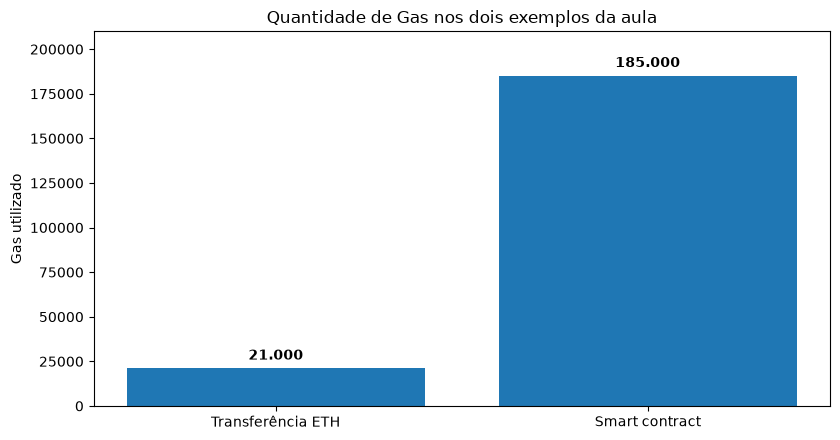

CENÁRIO 1: TRANSFERÊNCIA SIMPLES DE ETH (Gas Limit = 21.000)
  Gas Utilizado: 21.000 unidades
  Preço Efetivo do Gas: 32.0 Gwei (30.0 Base + 2.0 Priority)
  💸 Custo Total da Transação: 0.000672 ETH
  🔥 Parcela QUEIMADA (Base Fee): 0.000630 ETH (Destruída para sempre!)
  👤 Parcela do VALIDADOR (Tip):   0.000042 ETH

CENÁRIO 2: CHAMADA A SMART CONTRACT (DEX Swap - 185.000 Gas)
  Gas Utilizado: 185.000 unidades
  Preço Efetivo do Gas: 48.5 Gwei
  💸 Custo Total da Transação: 0.008972 ETH
  🔥 Parcela QUEIMADA:          0.008325 ETH
  👤 Parcela do Validador:     0.000647 ETH

SIMULAÇÃO DE AJUSTE AUTOMÁTICO DA BASE FEE ENTRE BLOCOS SUCESSIVOS
  Bloco 1 (Super Congestionado): Gas Gasto: 30,000,000 | Base Fee Atual: 20.00 Gwei -> Próxima Base Fee: 22.50 Gwei
  Bloco 2 (Congestionado): Gas Gasto: 22,500,000 | Base Fee Atual: 22.50 Gwei -> Próxima Base Fee: 23.91 Gwei
  Bloco 3 (Na Meta exata): Gas Gasto: 15,000,000 | Base Fee Atual: 23.91 Gwei -> Próxima Base Fee: 23.91 Gwei
  Bloco 4 (Pouco Uso

In [7]:
gas_exemplos = [21000, 185000]

nomes = ["Transferência ETH", "Smart contract"]

fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.bar(nomes, gas_exemplos)

ax.set_ylabel("Gas utilizado")

ax.set_title("Quantidade de Gas nos dois exemplos da aula")

for i, v in enumerate(gas_exemplos):
    ax.text(i, v + 5000, f"{v:,}".replace(",", "."), ha="center", fontweight="bold")

ax.set_ylim(0, 210000)

plt.tight_layout()

plt.show()

def gwei_para_wei(gwei: float) -> int:
    return int(gwei * 10**9)

def wei_para_eth(wei: int) -> float:
    return wei / 10**18

def calcular_taxa_transacao(gas_used: int, base_fee_gwei: float, priority_fee_gwei: float):
    base_fee_wei = gwei_para_wei(base_fee_gwei)
    priority_fee_wei = gwei_para_wei(priority_fee_gwei)
    gas_price_efetivo_wei = base_fee_wei + priority_fee_wei

    custo_total_wei = gas_used * gas_price_efetivo_wei
    custo_queimado_wei = gas_used * base_fee_wei
    recompensa_validador_wei = gas_used * priority_fee_wei

    return {
        "custo_total_eth": wei_para_eth(custo_total_wei),
        "queimado_eth": wei_para_eth(custo_queimado_wei),
        "validador_eth": wei_para_eth(recompensa_validador_wei),
        "gas_price_gwei": base_fee_gwei + priority_fee_gwei
    }

res_simples = calcular_taxa_transacao(gas_used=21000, base_fee_gwei=30.0, priority_fee_gwei=2.0)

print("=" * 80)

print("CENÁRIO 1: TRANSFERÊNCIA SIMPLES DE ETH (Gas Limit = 21.000)")

print("=" * 80)

print(f"  Gas Utilizado: 21.000 unidades")

print(f"  Preço Efetivo do Gas: {res_simples['gas_price_gwei']:.1f} Gwei (30.0 Base + 2.0 Priority)")

print(f"  💸 Custo Total da Transação: {res_simples['custo_total_eth']:.6f} ETH")

print(f"  🔥 Parcela QUEIMADA (Base Fee): {res_simples['queimado_eth']:.6f} ETH (Destruída para sempre!)")

print(f"  👤 Parcela do VALIDADOR (Tip):   {res_simples['validador_eth']:.6f} ETH")

res_contrato = calcular_taxa_transacao(gas_used=185000, base_fee_gwei=45.0, priority_fee_gwei=3.5)

print("\n" + "=" * 80)

print("CENÁRIO 2: CHAMADA A SMART CONTRACT (DEX Swap - 185.000 Gas)")

print("=" * 80)

print(f"  Gas Utilizado: 185.000 unidades")

print(f"  Preço Efetivo do Gas: {res_contrato['gas_price_gwei']:.1f} Gwei")

print(f"  💸 Custo Total da Transação: {res_contrato['custo_total_eth']:.6f} ETH")

print(f"  🔥 Parcela QUEIMADA:          {res_contrato['queimado_eth']:.6f} ETH")

print(f"  👤 Parcela do Validador:     {res_contrato['validador_eth']:.6f} ETH")

print("\n" + "=" * 80)

print("SIMULAÇÃO DE AJUSTE AUTOMÁTICO DA BASE FEE ENTRE BLOCOS SUCESSIVOS")

print("=" * 80)

ALVO_GAS = 15_000_000   # Meta de 15M de gas por bloco

MAX_GAS  = 30_000_000   # Teto de 30M

def simular_proximo_bloco(base_fee_atual, gas_utilizado_no_bloco):
    diferenca = gas_utilizado_no_bloco - ALVO_GAS
    # Fórmula EIP-1559: ajuste máximo de 12.5% (1/8)
    variacao = base_fee_atual * (diferenca / ALVO_GAS) * 0.125
    nova_base_fee = max(1.0, base_fee_atual + variacao)
    return nova_base_fee

base_fee = 20.0

historico_blocos = [
    ("Bloco 1 (Super Congestionado)", 30_000_000), # 100% cheio -> sobe 12.5%
    ("Bloco 2 (Congestionado)",       22_500_000), # Acima da meta -> sobe
    ("Bloco 3 (Na Meta exata)",       15_000_000), # Estável -> mantém
    ("Bloco 4 (Pouco Uso)",            5_000_000)  # Bem abaixo -> cai
]

for rotulo, gas_gasto in historico_blocos:
    proxima = simular_proximo_bloco(base_fee, gas_gasto)
    print(f"  {rotulo}: Gas Gasto: {gas_gasto:,} | Base Fee Atual: {base_fee:.2f} Gwei -> Próxima Base Fee: {proxima:.2f} Gwei")
    base_fee = proxima


### Visualização 4 — Como a Base Fee reage à ocupação do bloco
Aqui usamos os quatro blocos definidos na simulação da aula. O objetivo é observar a **direção da mudança**, não representar uma sequência histórica real da Ethereum.


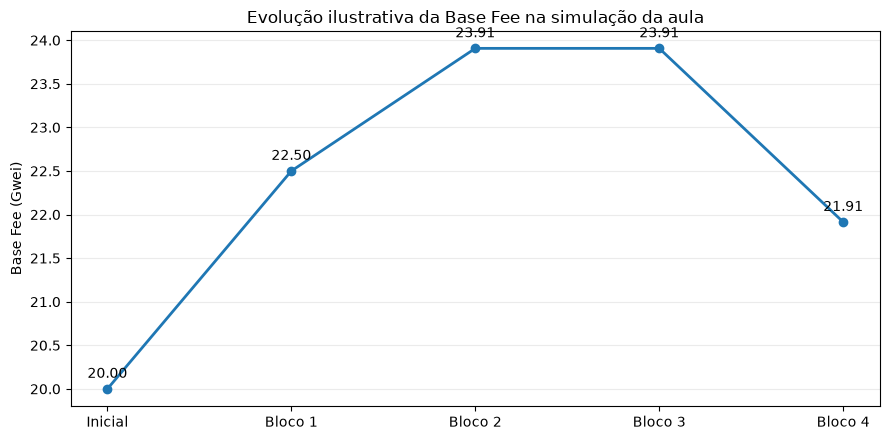

In [8]:
ALVO_GAS = 15_000_000

def simular_base_fee(base_fee_atual, gas_utilizado_no_bloco):
    diferenca = gas_utilizado_no_bloco - ALVO_GAS
    variacao = base_fee_atual * (diferenca / ALVO_GAS) * 0.125
    return max(1.0, base_fee_atual + variacao)

base_fee = 20.0

labels = ["Inicial"]

valores = [base_fee]

blocos = [
    ("Bloco 1", 30_000_000),
    ("Bloco 2", 22_500_000),
    ("Bloco 3", 15_000_000),
    ("Bloco 4", 5_000_000),
]

for rotulo, gas in blocos:
    base_fee = simular_base_fee(base_fee, gas)
    labels.append(rotulo)
    valores.append(base_fee)

fig, ax = plt.subplots(figsize=(9, 4.5))

ax.plot(labels, valores, marker="o", linewidth=2)

ax.set_ylabel("Base Fee (Gwei)")

ax.set_title("Evolução ilustrativa da Base Fee na simulação da aula")

ax.grid(axis="y", alpha=0.25)

for x, y in enumerate(valores):
    ax.annotate(f"{y:.2f}", (x, y), textcoords="offset points",
                xytext=(0, 8), ha="center")

plt.tight_layout()

plt.show()


### Visualização 5 — Para onde vai o valor pago pela transação?
Nos exemplos da calculadora, a taxa total pode ser separada em duas partes: **Base Fee**, que é queimada, e **Priority Fee**, que é direcionada ao validador. O gráfico abaixo usa os mesmos parâmetros dos dois cenários.


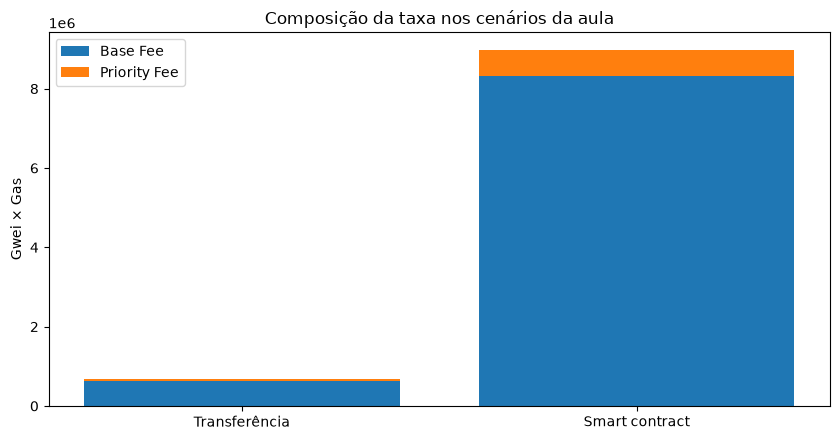

In [9]:
cenarios = ["Transferência", "Smart contract"]

base = [21000 * 30.0, 185000 * 45.0]

priority = [21000 * 2.0, 185000 * 3.5]

fig, ax = plt.subplots(figsize=(8.5, 4.5))

ax.bar(cenarios, base, label="Base Fee")

ax.bar(cenarios, priority, bottom=base, label="Priority Fee")

ax.set_ylabel("Gwei × Gas")

ax.set_title("Composição da taxa nos cenários da aula")

ax.legend()

plt.tight_layout()

plt.show()

### Da teoria para uma transação real
Até aqui, usamos exemplos controlados para entender o funcionamento. No laboratório, a lógica muda: **em vez de imaginar os dados, vamos procurar evidências de uma transação real no explorador de blocos**.

Pense no Etherscan como uma janela de inspeção da blockchain. Ele permite observar, entre outros elementos:
- quem enviou a transação;
- para onde ela foi;
- qual bloco a incluiu;
- quanto Gas foi usado;
- quais eventos o contrato emitiu;
- e quais dados foram enviados para o contrato.

O objetivo é aprender a **ler os sinais técnicos deixados pela execução**.

---
# 5. Laboratório Prático Dirigido (Hands-on - 40 min)
## Rastreamento e Dissecação Forense no Etherscan (Sepolia Testnet / Mainnet)

* **Objetivo do Laboratório:** Aplicar os conceitos de Máquina de Estado, contas EOA vs Contratos, métricas de Gas e identificação de anomalias computacionais inspecionando transações reais em um explorador de blocos (*Blockchain Explorer*).
* **Ambiente de Trabalho:** [https://sepolia.etherscan.io/](https://sepolia.etherscan.io/) (Rede de testes Sepolia) ou [https://etherscan.io/](https://etherscan.io/) (Mainnet).

---

### Atividade 1: Anatomia de uma Transferência Nativa Simples (EOA -> EOA)
Abra o Etherscan e navegue até uma transação simples de transferência de ETH (ou utilize uma transação exemplar pública de transferência).

#### Roteiro de Inspeção Técnica:
1. **Transaction Hash (TxHash):** Identificador exclusivo SHA-256/Keccak de 64 caracteres hexadecimais da transação.
2. **Status:** Confirme se o estado é `Success` (incorporado na cadeia canônica).
3. **Block:** Verifique o número do bloco e a quantidade de **Confirmações de Bloco (*Block Confirmations*)**.
4. **From / To:**
   * Constatar que o remetente (`From`) é um endereço de conta externa (*EOA*).
   * Constatar que o destinatário (`To`) é outra *EOA*.
5. **Value:** Quantia nominal transferida em ETH.
6. **Gas Limit vs. Gas Used by Transaction:**
   * Observe que para transferência simples entre duas carteiras, **o `Gas Used` é exatamente 21.000 unidades (100% de uso do Gas Limit)**.
7. **Gas Price e EIP-1559 Breakdown:**
   * Identifique os campos `Base Fee`, `Max Fee` e `Max Priority Fee`.
   * Verifique o campo `Burnt Fees` (quantidade exata de ETH queimada para sempre nessa transferência).

---

### Atividade 2: Dissecação de Interação com Smart Contract (EOA -> Contract)
Localize no explorador uma transação que interaja com um contrato inteligente (ex: transação em protocolo de Swap como Uniswap, transferência de token ERC-20 como USDT/USDC ou mint de ativo digital).

#### Roteiro de Inspeção Técnica:
1. **Identificação do Destinatário (`Interacted With (To)`):**
   * Observe o ícone de documento ao lado do endereço `To`, indicando que se trata de uma **Contract Account** com bytecode armazenado.
2. **Gas Limit vs. Gas Used by Transaction:**
   * Observe que aqui o `Gas Limit` foi estipulado em uma margem de segurança (ex: 200.000), mas o `Gas Used` foi menor (ex: 132.418 unidades, cerca de 66% de consumo efetivo).
   * Explique por que o usuário **recebe de volta o troco referente às unidades de Gas não utilizadas**.
3. **Decodificação de Dados de Entrada (*Input Data* / ABI):**
   * Role a página até a seção **Input Data**.
   * Clique em **View Input As: Default / Decoded**.
   * Identifique o **MethodID** (os primeiros 4 bytes do hash Keccak da assinatura da função, ex: `0xa9059cbb` para a função `transfer(address,uint256)`).
   * Identifique os parâmetros reais passados para a função (endereço de destino e quantidade de tokens codificados em hexadecimal de 32 bytes).
4. **Logs de Eventos (*Transaction Receipts Event Logs*):**
   * Clique na aba **Logs (Eventos emitidos)**.
   * Observe os eventos gerados pelos opcodes `LOG0-LOG4` da EVM (ex: evento `Transfer(address from, address to, uint256 value)`).
   * Constatar que sistemas externos de ERP/BI leem esses tópicos indexados para atualizar bancos de dados corporativos sem precisar reexecutar o contrato!

---

### Atividade 3: Análise Forense de Falha de Execução (*Out of Gas* / *Reverted*)
No campo de busca do Etherscan, filtre por transações com status de erro (`Fail` ou `Execution Reverted`).

#### Roteiro de Inspeção Técnica:
1. **Mensagem de Erro:**
   * Identifique se a falha ocorreu por **`Warning! Error encountered during contract execution [Out of gas]`** ou por violação de regra de negócio (`execution reverted: Insufficient balance`).
2. **Impacto no Gas Limit:**
   * Se o erro foi `Out of gas`, observe que o `Gas Used by Transaction` foi exatamente **100% do Gas Limit**. Todo o combustível foi queimado até a máquina virtual interromper o processo!
3. **Destino do Saldo Financeiro e Integridade do Contrato:**
   * O valor do campo `Value` (ETH transferido) saiu da carteira do remetente e foi para o contrato? **NÃO!** Devido à transição de estado atômica ($\sigma_{t+1} = \sigma_t$), a transferência de valor foi desfeita em rollback!
   * A taxa de transação (`Transaction Fee`) foi devolvida? **NÃO!** O validador reteve a taxa pelo custo de hardware de ter executado os opcodes até o limite.

---

### Ficha Técnica de Auditoria Forense (Entregável da Aula Prática)
Durante o laboratório de 40 minutos, cada estudante ou dupla deve selecionar **uma transação com interação de contrato inteligente** no Etherscan e preencher rigorosamente a ficha abaixo:

```markdown
================================================================================
FICHA TÉCNICA DE AUDITORIA FORENSE DE TRANSAÇÃO DLT (ETHERSCAN)
================================================================================
1. Identificação Geral:
   * Rede Analisada: [  ] Sepolia Testnet   [  ] Ethereum Mainnet
   * Transaction Hash (TxHash): 0x_____________________________________________
   * Número do Bloco / Confirmações: Bloco #______________ (_______ confirmações)
   * Timestamp UTC: ____/____/202___ às ____:____:____ UTC

2. Atores Envolvidos:
   * Conta Remetente (From - EOA): 0x___________________________________________
   * Conta Destinatária (To - Contrato): 0x_____________________________________
   * Nome do Contrato / Protocolo: _____________________________________________

3. Parâmetros Computacionais e Econômicos:
   * Limite de Gas Estipulado (Gas Limit): _______________ unidades
   * Gas Realmente Consumido (Gas Used): _________________ unidades
   * Eficiência de Consumo (Gas Used / Gas Limit): _________%
   * Base Fee do Bloco: ________________ Gwei
   * Priority Fee Paga (Tip): __________ Gwei
   * Taxa Total Paga em ETH: ___________ ETH (equiv. a R$ ____________)
   * Quantia de ETH Queimada (Burnt): ___ ETH

4. Decodificação da Chamada de Método (Input Data):
   * MethodID (4 primeiros bytes hex): 0x________________
   * Nome da Função Invocada no ABI: __________________________________________
   * Parâmetros Identificados:
     - Parâmetro [0]: _________________________________________________________
     - Parâmetro [1]: _________________________________________________________

5. Eventos Emitidos (Transaction Receipt Logs):
   * Nome do Evento Principal Emitido: _________________________________________
   * O que esse evento sinalizou para os sistemas corporativos externos?
     __________________________________________________________________________
================================================================================
```

### Síntese visual — conectando os quatro conceitos
A sequência abaixo organiza a aula inteira em uma cadeia de raciocínio:

**Consenso** define como a rede concorda → **transação** solicita uma mudança → **EVM** executa o código → **Gas** limita e mede o trabalho → **estado** é atualizado ou revertido.


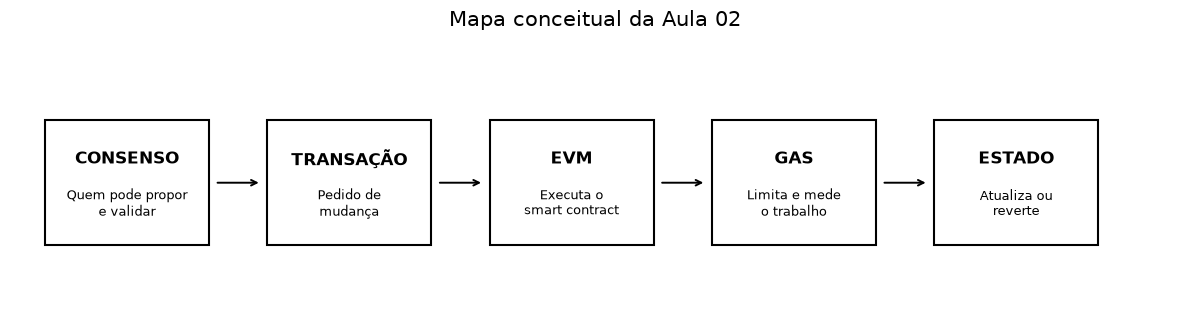

In [10]:
fig, ax = plt.subplots(figsize=(12, 3.4))

ax.axis("off")

etapas = [
    ("CONSENSO", "Quem pode propor\ne validar"),
    ("TRANSAÇÃO", "Pedido de\nmudança"),
    ("EVM", "Executa o\nsmart contract"),
    ("GAS", "Limita e mede\no trabalho"),
    ("ESTADO", "Atualiza ou\nreverte"),
]

for i, (titulo, desc) in enumerate(etapas):
    x = 0.03 + i * 0.19
    rect = plt.Rectangle((x, 0.27), 0.14, 0.45, fill=False, linewidth=1.5)
    ax.add_patch(rect)
    ax.text(x + 0.07, 0.58, titulo, ha="center", va="center",
            fontsize=12, fontweight="bold")
    ax.text(x + 0.07, 0.42, desc, ha="center", va="center", fontsize=9)
    if i < len(etapas) - 1:
        ax.annotate("", xy=(x + 0.185, 0.495), xytext=(x + 0.145, 0.495),
                    arrowprops=dict(arrowstyle="->", linewidth=1.4))

ax.set_xlim(0, 1)

ax.set_ylim(0, 1)

ax.set_title("Mapa conceitual da Aula 02", fontsize=15, pad=12)

plt.tight_layout()

plt.show()

---
# 6. Protocolo de Avaliação Formativa · Caderno de Exercícios da Aula 02
### Resolução Individual ou em Duplas (Caderno Oficial: `Aula02_Exercicios.ipynb`)

As atividades práticas e investigativas desta aula estão consolidadas no caderno dedicado **`Aula02_Exercicios.ipynb`**, combinando baixa complexidade de código com pesquisa ativa em exploradores de blocos e raciocínio de Sistemas de Informação:

---

### Síntese dos 6 Exercícios do Caderno:

#### **Exercício 1 · Investigação Forense no Etherscan (Sepolia Testnet)**
* **Objetivo:** Acessar o [Sepolia Etherscan](https://sepolia.etherscan.io/), coletar os metadados de uma transação real (TxHash, Bloco, From/To, Gas Limit vs. Gas Used, Base Fee e ETH Queimado) e analisar por que o *Gas Used* foi inferior ao limite estipulado e o destino do saldo não utilizado.

#### **Exercício 2 · Conversão de Unidades e Calculadora EIP-1559 em Python**
* **Objetivo:** Implementar em Python a conversão precisa de unidades monetárias (Wei, Gwei, ETH), pesquisar as homenagens históricas a **Wei Dai** e **Claude Shannon**, e calcular o custo de um Swap em DEX convertido para Reais (R$) na cotação financeira atual.

#### **Exercício 3 · Estudo de Caso Arquitetural: Escolhendo o Consenso Ideal**
* **Objetivo:** Analisar três cenários organizacionais reais:
  1. **Rede Interbancária do Real Digital (DREX / Banco Central)**;
  2. **Protocolo Global de Microempréstimos Descentralizados (DeFi)**;
  3. **Rastreabilidade de Vacinas entre 8 Indústrias Farmacêuticas e ANVISA**.
  * Recomendar fundamentadamente **PoW**, **PoS** ou **PoA** para cada caso à luz do Trilema da Blockchain.

#### **Exercício 4 · Investigação Forense: Transação com Falha "Out of Gas"**
* **Objetivo:** Localizar no explorador uma transação que falhou por falta de gas (`Out of Gas`). Explicar por que o validador retém a taxa consumida enquanto o valor principal em ETH é preservado pelo **Rollback Atômico da EVM** ($\sigma_{t+1} = \sigma_t$).

#### **Exercício 5 · O Guardião do Estado: Proteção Anti-Replay com `nonce`**
* **Objetivo:** Completar uma rotina em Python que valida o campo `nonce` em contas Ethereum para detectar e bloquear sumariamente tentativas de **Replay Attack** (duplicação de transações assinadas).

#### **Exercício 6 · Investigação no Beaconcha.in: A Camada de Consenso da Ethereum**
* **Objetivo:** Consultar a camada de consenso PoS no explorador [Beaconcha.in](https://beaconcha.in/), levantar o total de validadores e ETH em staking, e inspecionar um caso real de validador que sofreu **Slashing**, identificando a infração cometida.

---

### Rubrica de Avaliação Formativa:
| Critério de Desempenho | Insuficiente (0-4) | Regular (5-7) | Excelente (8-10) |
| :--- | :--- | :--- | :--- |
| **Investigação Forense (Etherscan & Beaconcha.in)** | Não encontrou os dados ou utilizou valores genéricos sem evidência real de transação/validador. | Coletou os dados no explorador, mas cometeu imprecisões ao interpretar Gas Limit, Base Fee ou Slashing. | Dissecou com precisão forense a transação real, interpretou taxas, hashes, queima de ETH e eventos de consenso. |
| **Aplicação Prática em Código (Python)** | Não implementou o cálculo da EIP-1559 nem a validação de nonce, deixando células com erro de sintaxe. | Implementou as funções com pequenos deslizes de conversão ou lógica sem comentar o resultado. | Implementou com perfeição as conversões (Wei/Gwei/ETH) e a regra anti-replay por incremento estrito de nonce. |
| **Raciocínio Arquitetural (Estudo de Caso)** | Sugeriu consensos aleatórios sem relação com o problema ou sem considerar o Trilema da Blockchain. | Identificou o consenso correto para a maioria dos casos, mas com fundamentação teórica rasa. | Articulou com clareza o Trilema de Buterin, trade-offs de latência, governança jurídica e custo empresarial. |

---
# 7. Bibliografia Canônica e Próximos Passos

### Gancho Pedagógico para a Próxima Aula (Aula 03):
Na **Aula 03**, passaremos da arquitetura da máquina virtual para o desenvolvimento prático de aplicações descentralizadas:
* Dominaremos a linguagem de programação **Solidity**: variáveis de estado, modificadores de acesso (`onlyOwner`, `payable`), interfaces e emissão de eventos.
* Estudaremos os padrões de tokens mais influentes da economia digital: **ERC-20** (tokens fungíveis) e **ERC-721/1155** (tokens não-fungíveis / NFTs).
* Desenvolveremos, compilaremos e faremos o deploy prático de um Smart Contract de rastreabilidade de cadeia de suprimentos (*Supply Chain*) e **Tokenização de Ativos do Mundo Real (*Real World Assets - RWA*)** utilizando o ambiente web *Remix IDE*.

---

### Bibliografia Canônica e Obras de Referência:
1. **BUTERIN, Vitalik.** *Ethereum: A Next-Generation Smart Contract and Decentralized Application Platform (Ethereum Whitepaper)*. 2014. Disponível em: <https://ethereum.org/en/whitepaper/>.
2. **WOOD, Gavin.** *Ethereum: A Secure Decentralised Generalised Transaction Ledger (Ethereum Yellow Paper)*. Berlin Version, 2014–2024. Disponível em: <https://ethereum.github.io/yellowpaper/paper.pdf>.
3. **ANTONOPOULOS, Andreas M.; WOOD, Gavin.** *Mastering Ethereum: Building Smart Contracts and DApps*. Sebastopol: O'Reilly Media, 2018. ISBN 978-1491971949.
4. **BUTERIN, Vitalik; CONNER, Eric; DUDDY, Rick; SISSON, Matthew; GREEN, Ian.** *EIP-1559: Fee market change for ETH 1.0 chain*. Ethereum Improvement Proposals, n. 1559, 2019. Disponível em: <https://eips.ethereum.org/EIPS/eip-1559>.
5. **CASTRO, Miguel; LISKOV, Barbara.** *Practical Byzantine Fault Tolerance and Proactive Recovery*. ACM Transactions on Computer Systems (TOCS), v. 20, n. 4, p. 398-461, 2002.
6. **TURING, Alan M.** *On Computable Numbers, with an Application to the Entscheidungsproblem*. Proceedings of the London Mathematical Society, v. s2-42, n. 1, p. 230-265, 1936.
7. **LAMPORT, Leslie; SHOSTAK, Robert; PEASE, Marshall.** *The Byzantine Generals Problem*. ACM Transactions on Programming Languages and Systems, v. 4, n. 3, p. 382-401, 1982.
8. **ETHEREUM FOUNDATION.** *Ethereum Developer Documentation: Consensus Mechanisms, Proof of Stake, EVM and Gas*. 2024. Disponível em: <https://ethereum.org/en/developers/docs/>.
9. **ETHERSCAN TEAM.** *Etherscan: Ethereum (Sepolia) Block Explorer and Analytics Platform*. Disponível em: <https://sepolia.etherscan.io/>.